Mejor solución encontrada:
x = 0.3298100994206423
f(x) = 15.0702567886123


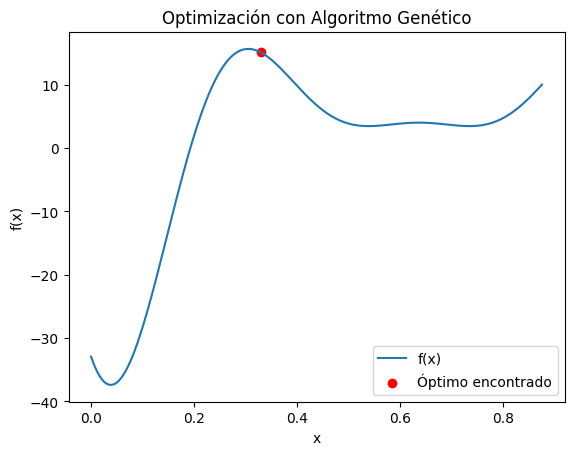

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# FUNCIÓN OBJETIVO (EJERCICIO)

def objfun(x):
    return 1 - (11*x - 7)**2 * np.cos(11*x - 7) + 1 + 2



# CREAR POBLACIÓN

def creapob(Nind, Lind):
    return np.random.randint(0, 2, size=(Nind, Lind))



# DECODIFICACIÓN BINARIA

def decodifica(genotipo, xmin, xmax):
    Nind, Lind = genotipo.shape
    potencias = 2 ** np.arange(Lind)

    valores = np.dot(genotipo, potencias)
    x = xmin + (xmax - xmin) * valores / (2**Lind - 1)

    return x



# SELECCIÓN POR RULETA

def ruleta(genotipo, fitness):
    total = np.sum(fitness)
    prob = fitness / total
    acum = np.cumsum(prob)

    Nind = len(fitness)
    idx = []

    for _ in range(Nind):
        r = np.random.rand()
        for i in range(Nind):
            if acum[i] >= r:
                idx.append(i)
                break

    return genotipo[idx]



# CRUZA (UN PUNTO)

def cruzamiento(poblacion, Pc):
    Nind, Lind = poblacion.shape
    nueva = np.copy(poblacion)

    for i in range(0, Nind - 1, 2):
        if np.random.rand() <= Pc:
            punto = np.random.randint(1, Lind - 1)

            nueva[i, punto:], nueva[i+1, punto:] = (
                poblacion[i+1, punto:].copy(),
                poblacion[i, punto:].copy()
            )

    return nueva



# MUTACIÓN

def mutacion(poblacion, Pm):
    Nind, Lind = poblacion.shape
    mut = np.random.rand(Nind, Lind) < Pm
    return np.logical_xor(poblacion, mut).astype(int)



# PARÁMETROS (DEL EJERCICIO)

Nind = 5            # población
Lind = 20           # longitud del individuo
Pc = 0.7            # prob. cruza
Pm = 1/15           # prob. mutación
Maxgen = 100        # generaciones

xmin = 0
xmax = 0.875



# INICIALIZACIÓN

poblacion = creapob(Nind, Lind)

mejor_hist = []
mejor_x = []



# CICLO EVOLUTIVO

for gen in range(Maxgen):

    # Decodificar
    x = decodifica(poblacion, xmin, xmax)

    # Evaluar
    fx = objfun(x)

    # Guardar mejor
    idx = np.argmax(fx)
    mejor_hist.append(fx[idx])
    mejor_x.append(x[idx])

    # Fitness (evitar negativos)
    fitness = fx - np.min(fx) + 1e-6

    # Selección
    poblacion = ruleta(poblacion, fitness)

    # Cruza
    poblacion = cruzamiento(poblacion, Pc)

    # Mutación
    poblacion = mutacion(poblacion, Pm)



# RESULTADOS

print("Mejor solución encontrada:")
print("x =", mejor_x[-1])
print("f(x) =", mejor_hist[-1])



# GRÁFICA

x_vals = np.linspace(xmin, xmax, 200)
y_vals = objfun(x_vals)

plt.plot(x_vals, y_vals, label="f(x)")
plt.scatter(mejor_x[-1], mejor_hist[-1], color='red', label="Óptimo encontrado")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Optimización con Algoritmo Genético")
plt.legend()
plt.show()